<a href="https://colab.research.google.com/github/Sairakesh08/Ensuring-Skin-Cancer/blob/main/Dataloading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_dir = '/content/ISIC_2019/'
os.makedirs(dataset_dir, exist_ok=True)

!wget -O {dataset_dir}ISIC_2019_Training_Input.zip https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_Input.zip
!wget -O {dataset_dir}ISIC_2019_Training_Metadata.csv https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_Metadata.csv
!wget -O {dataset_dir}ISIC_2019_Training_GroundTruth.csv https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_GroundTruth.csv

!wget -O {dataset_dir}ISIC_2019_Test_Input.zip https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_Input.zip
!wget -O {dataset_dir}ISIC_2019_Test_Metadata.csv https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_Metadata.csv
!wget -O {dataset_dir}ISIC_2019_Test_GroundTruth.csv https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_GroundTruth.csv


--2025-01-30 19:36:11--  https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_Input.zip
Resolving isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)... 3.5.25.250, 52.217.235.137, 3.5.1.196, ...
Connecting to isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)|3.5.25.250|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9771618190 (9.1G) [application/zip]
Saving to: ‘/content/ISIC_2019/ISIC_2019_Training_Input.zip’

/content/ISIC_2019/ 100%[===================>]   9.10G  80.9MB/s    in 2m 10s  

2025-01-30 19:38:22 (71.4 MB/s) - ‘/content/ISIC_2019/ISIC_2019_Training_Input.zip’ saved [9771618190/9771618190]

--2025-01-30 19:38:22--  https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_Metadata.csv
Resolving isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)... 3.5.6.157, 52.217.160.113, 16.15.177.233, ...
Connecting to isic-challenge-data.s3.amazonaws.com (i

In [ ]:
import os

dataset_dir = '/content/ISIC_2019/'
files = os.listdir(dataset_dir)
print("Downloaded files:")
for file in files:
    print(file)

Downloaded files:
ISIC_2019_Training_GroundTruth.csv
test_images
ISIC_2019_Test_Metadata.csv
training_images
ISIC_2019_Training_Input.zip
ISIC_2019_Test_GroundTruth.csv
ISIC_2019_Test_Input.zip
ISIC_2019_Training_Metadata.csv


In [ ]:
import os
import zipfile
import shutil

dataset_dir = '/content/ISIC_2019/'

train_zip_path = os.path.join(dataset_dir, 'ISIC_2019_Training_Input.zip')
test_zip_path = os.path.join(dataset_dir, 'ISIC_2019_Test_Input.zip')

train_extract_path = os.path.join(dataset_dir, 'training_images')
test_extract_path = os.path.join(dataset_dir, 'test_images')

os.makedirs(train_extract_path, exist_ok=True)
os.makedirs(test_extract_path, exist_ok=True)

with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall(train_extract_path)

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
train_image_folder = os.path.join(train_extract_path, 'ISIC_2019_Training_Input')
test_image_folder = os.path.join(test_extract_path, 'ISIC_2019_Test_Input')

def move_images(source_folder, destination_folder):
    for filename in os.listdir(source_folder):
        source_path = os.path.join(source_folder, filename)
        dest_path = os.path.join(destination_folder, filename)
        shutil.move(source_path, dest_path)
    print(f"Moved {len(os.listdir(destination_folder))} images to {destination_folder}")

move_images(train_image_folder, train_extract_path)

move_images(test_image_folder, test_extract_path)


Moved 25334 images to /content/ISIC_2019/training_images
Moved 8241 images to /content/ISIC_2019/test_images


In [ ]:
print("\n Final Training Images List:")
print(os.listdir(train_extract_path)[:5])

print("\n Final Test Images List:")
print(os.listdir(test_extract_path)[:5])



 Final Training Images List:
['ISIC_0064969.jpg', 'ISIC_0064961.jpg', 'ISIC_0068661.jpg', 'ISIC_0026647.jpg', 'ISIC_0012187_downsampled.jpg']

 Final Test Images List:
['ISIC_0063065.jpg', 'ISIC_0058590.jpg', 'ISIC_0035470.jpg', 'ISIC_0063351.jpg', 'ISIC_0072310.jpg']


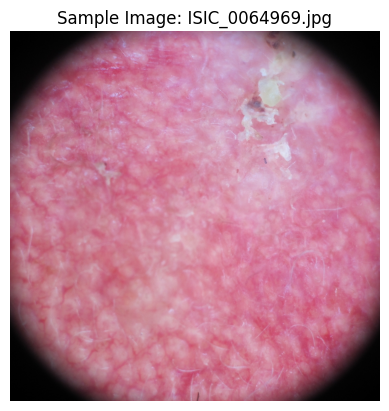

In [ ]:
import cv2
import matplotlib.pyplot as plt

sample_image_name = os.listdir(train_extract_path)[0]
sample_image_path = os.path.join(train_extract_path, sample_image_name)

image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title(f"Sample Image: {sample_image_name}")
plt.axis("off")
plt.show()


In [ ]:
import pandas as pd

train_metadata_path = os.path.join(dataset_dir, 'ISIC_2019_Training_Metadata.csv')
test_metadata_path = os.path.join(dataset_dir, 'ISIC_2019_Test_Metadata.csv')

train_groundtruth_path = os.path.join(dataset_dir, 'ISIC_2019_Training_GroundTruth.csv')
test_groundtruth_path = os.path.join(dataset_dir, 'ISIC_2019_Test_GroundTruth.csv')

train_metadata = pd.read_csv(train_metadata_path)
test_metadata = pd.read_csv(test_metadata_path)

train_groundtruth = pd.read_csv(train_groundtruth_path)
test_groundtruth = pd.read_csv(test_groundtruth_path)

print(" Training Metadata Sample:\n", train_metadata.head())
print("\n Training Ground Truth Sample:\n", train_groundtruth.head())


 Training Metadata Sample:
           image  age_approx anatom_site_general lesion_id     sex
0  ISIC_0000000        55.0      anterior torso       NaN  female
1  ISIC_0000001        30.0      anterior torso       NaN  female
2  ISIC_0000002        60.0     upper extremity       NaN  female
3  ISIC_0000003        30.0     upper extremity       NaN    male
4  ISIC_0000004        80.0     posterior torso       NaN    male

 Training Ground Truth Sample:
           image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


# New Section

In [ ]:
print("\nMissing values in Training Metadata:")
print(train_metadata.isnull().sum())

print("\nMissing values in Training Ground Truth:")
print(train_groundtruth.isnull().sum())



Missing values in Training Metadata:
image                     0
age_approx              437
anatom_site_general    2631
lesion_id              2084
sex                     384
dtype: int64

Missing values in Training Ground Truth:
image    0
MEL      0
NV       0
BCC      0
AK       0
BKL      0
DF       0
VASC     0
SCC      0
UNK      0
dtype: int64


In [ ]:
train_metadata['age_approx'].fillna(train_metadata['age_approx'].median(), inplace=True)

train_metadata['sex'].fillna(train_metadata['sex'].mode()[0], inplace=True)
train_metadata['anatom_site_general'].fillna(train_metadata['anatom_site_general'].mode()[0], inplace=True)

train_metadata.drop(columns=['lesion_id'], inplace=True, errors='ignore')

print("\n Missing values after handling:")
print(train_metadata.isnull().sum())



✅ Missing values after handling:
image                  0
age_approx             0
anatom_site_general    0
sex                    0
dtype: int64


<ipython-input-23-b8e0621e4581>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_metadata['age_approx'].fillna(train_metadata['age_approx'].median(), inplace=True)
<ipython-input-23-b8e0621e4581>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [ ]:
import zipfile

with zipfile.ZipFile(f'{dataset_dir}ISIC_2019_Training_Input.zip', 'r') as zip_ref:
    zip_ref.extractall(f'{dataset_dir}training_images/')

with zipfile.ZipFile(f'{dataset_dir}ISIC_2019_Test_Input.zip', 'r') as zip_ref:
    zip_ref.extractall(f'{dataset_dir}test_images/')


In [ ]:
print("Training Images Directory:")
print(os.listdir(f'{dataset_dir}training_images/')[:5])

print("\nTest Images Directory:")
print(os.listdir(f'{dataset_dir}test_images/')[:5])


Training Images Directory:
['ISIC_2019_Training_Input']

Test Images Directory:
['ISIC_2019_Test_Input']


In [ ]:
import pandas as pd

training_metadata = pd.read_csv(f'{dataset_dir}ISIC_2019_Training_Metadata.csv')
training_groundtruth = pd.read_csv(f'{dataset_dir}ISIC_2019_Training_GroundTruth.csv')

test_metadata = pd.read_csv(f'{dataset_dir}ISIC_2019_Test_Metadata.csv')
test_groundtruth = pd.read_csv(f'{dataset_dir}ISIC_2019_Test_GroundTruth.csv')

print("Training Metadata:")
print(training_metadata.head())

print("\nTraining Ground Truth:")
print(training_groundtruth.head())


Training Metadata:
          image  age_approx anatom_site_general lesion_id     sex
0  ISIC_0000000        55.0      anterior torso       NaN  female
1  ISIC_0000001        30.0      anterior torso       NaN  female
2  ISIC_0000002        60.0     upper extremity       NaN  female
3  ISIC_0000003        30.0     upper extremity       NaN    male
4  ISIC_0000004        80.0     posterior torso       NaN    male

Training Ground Truth:
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


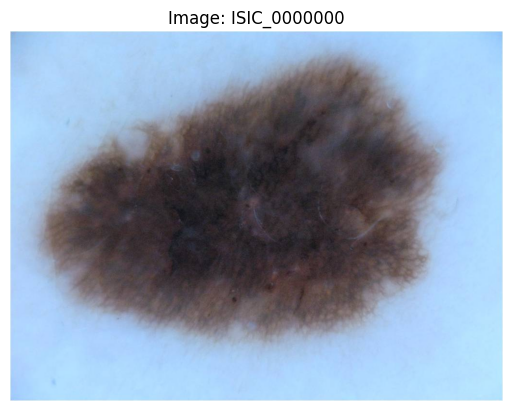

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_folder = '/content/ISIC_2019/training_images/ISIC_2019_Training_Input/'

example_image_id = 'ISIC_0000000'
example_image_path = f"{image_folder}{example_image_id}.jpg"

example_image = cv2.imread(example_image_path)
example_image = cv2.cvtColor(example_image, cv2.COLOR_BGR2RGB)

plt.imshow(example_image)
plt.title(f"Image: {example_image_id}")
plt.axis('off')
plt.show()


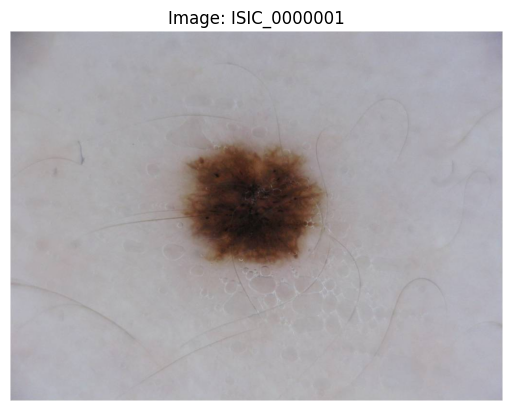

In [ ]:
second_image_id = 'ISIC_0000001'
second_image_path = f"{image_folder}{second_image_id}.jpg"

second_image = cv2.imread(second_image_path)
second_image = cv2.cvtColor(second_image, cv2.COLOR_BGR2RGB)

plt.imshow(second_image)
plt.title(f"Image: {second_image_id}")
plt.axis('off')
plt.show()


In [ ]:
import os
print(os.listdir(image_folder)[:5])


['ISIC_0064969.jpg', 'ISIC_0064961.jpg', 'ISIC_0068661.jpg', 'ISIC_0026647.jpg', 'ISIC_0012187_downsampled.jpg']


In [ ]:
missing_metadata = training_metadata.isnull().sum()
print("Missing values in Training Metadata:\n", missing_metadata)

Missing values in Training Metadata:
 image                     0
age_approx              437
anatom_site_general    2631
lesion_id              2084
sex                     384
dtype: int64


In [ ]:
missing_groundtruth = training_groundtruth.isnull().sum()
print("Missing values in Training Ground Truth:\n", missing_groundtruth)

Missing values in Training Ground Truth:
 image    0
MEL      0
NV       0
BCC      0
AK       0
BKL      0
DF       0
VASC     0
SCC      0
UNK      0
dtype: int64
